# 04 · OLS Regression on Log Returns

Predict next-day log return from technical indicators using Ordinary Least Squares regression and evaluate residual diagnostics.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
import config

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({'figure.dpi': config.FIG_DPI})

## 1. Load Features

In [ ]:
df = pd.read_csv(
    config.PROCESSED_DATA_CSV,
    index_col='Date', parse_dates=True
)
# Predict NEXT-day log return
df['LogReturn_next'] = df['LogReturn'].shift(-1)
df = df.dropna()

FEATURES = ['MA_cross', 'Volatility', 'RSI', 'BB_width', 'BB_pct']
X = df[FEATURES]
y = df['LogReturn_next']
print(f'Asset: {config.ASSET_NAME} ({config.ASSET_TICKER})')
print(f'X shape: {X.shape}   y shape: {y.shape}')

X shape: (3892, 5)   y shape: (3892,)


## 2. Fit OLS Model

In [3]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         LogReturn_next   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.061
Date:                Mon, 06 Apr 2026   Prob (F-statistic):              0.380
Time:                        10:23:31   Log-Likelihood:                 12023.
No. Observations:                3892   AIC:                        -2.403e+04
Df Residuals:                    3886   BIC:                        -2.400e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.002      0.358      0.7

## 3. In-Sample Predictions

In [4]:
y_pred = model.fittedvalues
residuals = model.resid

print(f'R²       = {model.rsquared:.4f}')
print(f'Adj. R²  = {model.rsquared_adj:.4f}')
print(f'AIC      = {model.aic:.2f}')
print(f'BIC      = {model.bic:.2f}')

R²       = 0.0014
Adj. R²  = 0.0001
AIC      = -24033.35
BIC      = -23995.75


## 4. Residual Diagnostics

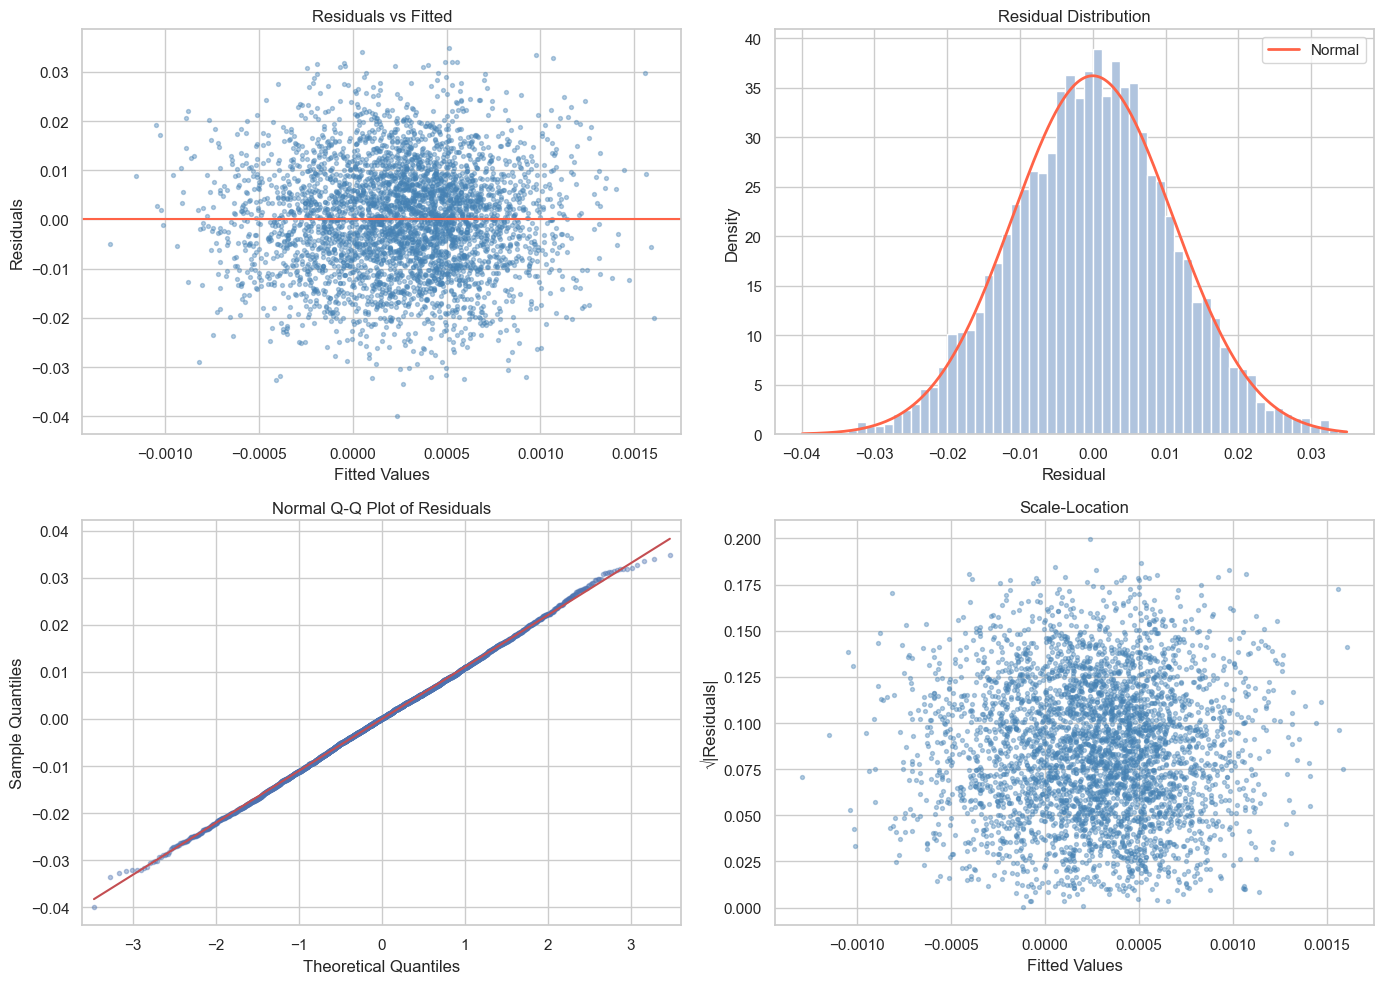

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4a – Residuals vs Fitted
axes[0, 0].scatter(y_pred, residuals, s=8, alpha=0.4, color='steelblue')
axes[0, 0].axhline(0, color='tomato', linewidth=1.5)
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# 4b – Residual histogram
axes[0, 1].hist(residuals, bins=60, density=True, color='lightsteelblue', edgecolor='white')
x_r = np.linspace(residuals.min(), residuals.max(), 300)
axes[0, 1].plot(x_r, stats.norm.pdf(x_r, residuals.mean(), residuals.std()),
                'tomato', linewidth=2, label='Normal')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# 4c – Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1, 0], alpha=0.4, markersize=3)
axes[1, 0].set_title('Normal Q-Q Plot of Residuals')

# 4d – Scale-Location
axes[1, 1].scatter(y_pred, np.sqrt(np.abs(residuals)), s=8, alpha=0.4, color='steelblue')
axes[1, 1].set_title('Scale-Location')
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('√|Residuals|')

plt.tight_layout()
plt.show()

- Residual diagnostics check if OLS assumptions are reasonable.
- Random scatter around zero suggests better fit; visible patterns suggest missing structure.
- Q-Q and Scale-Location panels help assess normality and constant variance of errors.

## 5. Coefficient Plot

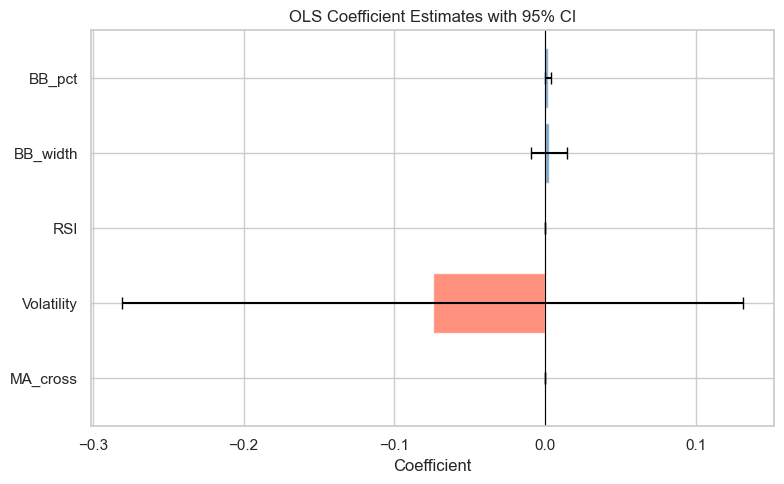

In [6]:
coefs = model.params.drop('const')
ci    = model.conf_int().drop('const')

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(coefs))
ax.barh(y_pos, coefs, color=['tomato' if c < 0 else 'steelblue' for c in coefs],
        alpha=0.7, edgecolor='white')
ax.errorbar(coefs, y_pos,
            xerr=[coefs - ci[0], ci[1] - coefs],
            fmt='none', color='black', capsize=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(coefs.index)
ax.set_title('OLS Coefficient Estimates with 95% CI')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

- Bars show coefficient estimates with 95% confidence intervals.
- If an interval crosses zero, that feature may have weak linear effect.
- Larger absolute coefficients indicate stronger linear contribution in the model.

## 6. Breusch-Pagan & Durbin-Watson Tests

In [7]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_const)
dw = durbin_watson(residuals)
print(f'Breusch-Pagan test  stat={bp_stat:.4f}  p={bp_p:.4e}')
print(f'Durbin-Watson stat  = {dw:.4f}  (2.0 → no autocorrelation)')

Breusch-Pagan test  stat=3.2407  p=6.6293e-01
Durbin-Watson stat  = 1.9709  (2.0 → no autocorrelation)
